# Supplementary Figures 

## Predicted Aligned Error Graphs | S1

### AK2

In [80]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.pylab import *

def plot_pae(json_filename, output_file_name="PAE_plot"):
    """
    Loads AlphaFold/ColabFold JSON data, plots the PAE heatmap, 
    and includes pTM/ipTM scores in the legend.
    """
    
    # 1. Load the JSON data
    try:
        with open(json_filename, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_filename}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{json_filename}'. Check file integrity.")
        return

    # Handle the common AlphaFold/ColabFold JSON format (list containing a dictionary)
    if isinstance(data, list) and len(data) > 0:
        data = data[0]

    # 2. Extract PAE matrix and scores
    try:
        pae_data = np.array(data["pae"])
        
        # Safely extract scores, handling cases where they might be wrapped in lists
        ptm = data.get("ptm", data.get("all_ptm", 0.0))
        iptm = data.get("iptm", data.get("all_iptm", 0.0))
        
        # Extract the score value if it's a list (common when extracted from .pkl)
        ptm_val = ptm[0] if isinstance(ptm, list) and ptm else ptm
        iptm_val = iptm[0] if isinstance(iptm, list) and iptm else iptm

        # Get the max PAE value for the color scale, defaulting to 31.75 Å
        max_pae = data.get("max_predicted_aligned_error", 31.75)
        vmax_value = min(30.0, max_pae) # Often capped at 30.0 Å for visualization

    except KeyError as e:
        print(f"Error: Missing expected key in JSON data: {e}. Cannot plot.")
        return

    # 3. Create the plot
    fig, ax = plt.subplots(figsize=(7, 9))
    
    # Draw PAE graph (Heatmap)
    # Greens_r: Reverse Greens. Darker color = lower error (better confidence)
    im = ax.imshow(pae_data, cmap=plt.cm.Greens_r, vmin=0, vmax=vmax_value)
    
    # Make adjustments for the color bar
    cbar = ax.figure.colorbar(im, ax=ax, orientation='horizontal', pad=0.12)
    
    # Set color bar label with pTM/ipTM scores
    cbar.set_label(
        # r"" allows for LaTeX formatting of Ångströms (A)
        r"Expected position error ($\mathrm{\AA}$)" + "\n\n" + 
        f"ptm={ptm_val:.3f}  iptm={iptm_val:.3f}", 
        fontsize=18
    )
    
    # Set tick sizes
    cbar.ax.tick_params(labelsize=18)
    plt.xlabel("Scored residue", fontsize=18)
    plt.ylabel("Aligned residue", fontsize=18)
    ax.tick_params(labelsize=24) # Set main axis tick label size
    #ax.axvline(x=239, color='red', linestyle='--', linewidth=2, alpha=0.7)
    #ax.axhline(y=239, color='red', linestyle='--', linewidth=2, alpha=0.7)

    # Ensure everything fits nicely
    fig.tight_layout()

    # 4. Save graph
    save_path = f'{output_file_name}_PAE.jpeg'
    fig.savefig(save_path, dpi=500, bbox_inches='tight')
    print(f"   ptm: {ptm_val:.3f}, iptm: {iptm_val:.3f}")

In [81]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.pylab import *

def plot_pae_zoomed(json_filename, start_res, end_res):
    """
    Loads AlphaFold/ColabFold JSON data, plots the PAE heatmap zoomed 
    to a specific residue range, displays PAE scores in each box, 
    and includes pTM/ipTM scores in the legend.
    
    The plot will cover the residue range [start_res, end_res] (inclusive).
    """
    
    # --- 1. Load and Process Data ---
    try:
        with open(json_filename, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{json_filename}' was not found.")
        return
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from '{json_filename}'. Check file integrity.")
        return

    # Handle the common JSON format (list containing a dictionary)
    if isinstance(data, list) and len(data) > 0:
        data = data[0]

    # 2. Extract PAE matrix and scores
    try:
        # Use 'pae' key based on your file's structure
        pae_data = np.array(data["pae"])
        
        # Safely extract scores. 'iptm' defaults to 0.0 if not present.
        ptm = data.get("ptm", 0.0)
        iptm = data.get("iptm", 0.0)
        
        # Extract the score value if it's a list
        ptm_val = ptm[0] if isinstance(ptm, list) and ptm else ptm
        iptm_val = iptm[0] if isinstance(iptm, list) and iptm else iptm

        # Get the max PAE value for the color scale, using 'max_pae' key or defaulting
        max_pae = data.get("max_pae", 31.75) 
        vmax_value = min(30.0, max_pae) 

    except KeyError as e:
        print(f"Error: Missing expected key in JSON data: {e}. Cannot plot.")
        return

    # --- 3. Slice the PAE data for the zoomed region ---
    # Convert 1-indexed residue numbers to 0-indexed slicing
    start_idx = start_res - 1
    end_idx = end_res 
    
    # Check if the requested range is valid
    if start_idx < 0 or end_idx > pae_data.shape[0] or start_idx >= end_idx:
        print(f"Error: Requested range [{start_res}-{end_res}] is invalid or outside the bounds of the PAE data (length {pae_data.shape[0]}).")
        return
    
    pae_data_zoomed = pae_data[start_idx:end_idx, start_idx:end_idx]

    # --- 4. Create the Plot ---
    fig, ax = plt.subplots(figsize=(8, 8)) # Increase size for better text visibility
    
    # Draw PAE graph (Heatmap)
    im = ax.imshow(pae_data_zoomed, cmap=plt.cm.Greens_r, vmin=0, vmax=vmax_value)
    
    # --- Annotate each cell with its PAE score ---
    for i in range(pae_data_zoomed.shape[0]):
        for j in range(pae_data_zoomed.shape[1]):
            value = pae_data_zoomed[i, j]
            # Use white text, .2f format, and center alignment
            ax.text(j, i, f'{value:.2f}', 
                    ha='center', va='center', 
                    color='white', 
                    fontsize=8, 
                    fontweight='bold') 
    
    # --- 5. Set custom ticks and labels for the zoomed region ---
    num_residues_zoomed = pae_data_zoomed.shape[0]
    
    # Tick positions: [0, 1, ..., N-1]
    tick_positions = np.arange(num_residues_zoomed)
    
    # Tick labels: [start_res, ..., end_res]
    tick_labels = np.arange(start_res, end_res + 1).astype(str)
    
    # Set the positions first
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)

    # Set the labels with rotation for readability (Fixes ValueError)
    ax.set_xticklabels(tick_labels, fontsize=12, rotation=90) 
    ax.set_yticklabels(tick_labels, fontsize=12)
    

    # Set tick sizes
    plt.xlabel("Scored residue", fontsize=16)
    plt.ylabel("Aligned residue", fontsize=16)

    # Ensure everything fits nicely
    fig.tight_layout()

    # --- 7. Save graph ---
    output_base_name = os.path.splitext(json_filename)[0]
    save_path = f'{output_base_name}_PAE_Zoom_{start_res}-{end_res}_Annotated.jpeg'
    fig.savefig(save_path, dpi=500, bbox_inches='tight')

#### Raw plotting

   ptm: 0.850, iptm: 0.000


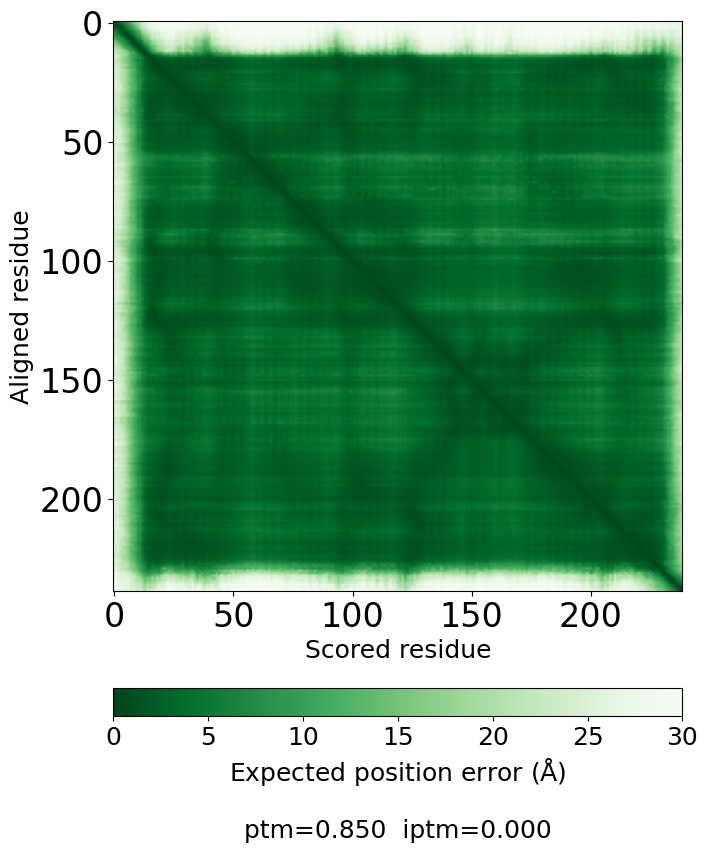

In [82]:
if __name__ == "__main__":
    input_json_file = "/Users/busra/Library/CloudStorage/GoogleDrive-busra.savas@ibg.edu.tr/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-seed5/pae/ak2-seed5_0_scores_rank_001_alphafold2_ptm_model_3_seed_000.json"
    output_base_name = os.path.splitext(input_json_file)[0]
    
    plot_pae(input_json_file, output_base_name)

#### Close-up view for residue 230-239

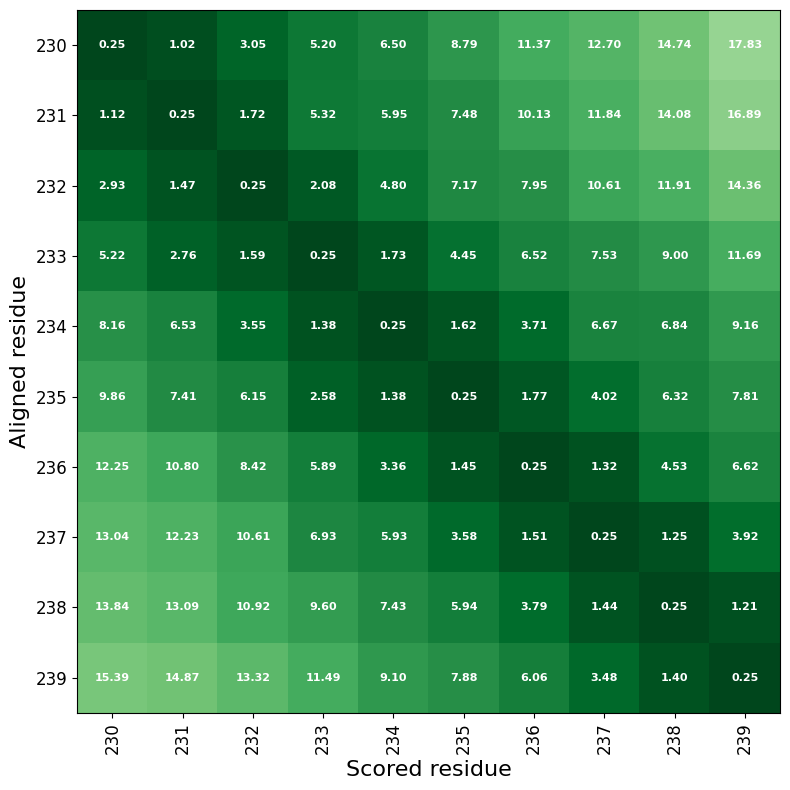

In [83]:
if __name__ == "__main__":
    input_json_file = "/Users/busra/Library/CloudStorage/GoogleDrive-busra.savas@ibg.edu.tr/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-seed5/pae/ak2-seed5_0_scores_rank_001_alphafold2_ptm_model_3_seed_000.json"
    start_residue_number = 230
    end_residue_number = 239

    plot_pae_zoomed(input_json_file, start_residue_number, end_residue_number)

### AK2/AIFM1

#### Raw plotting

   ptm: 0.740, iptm: 0.710


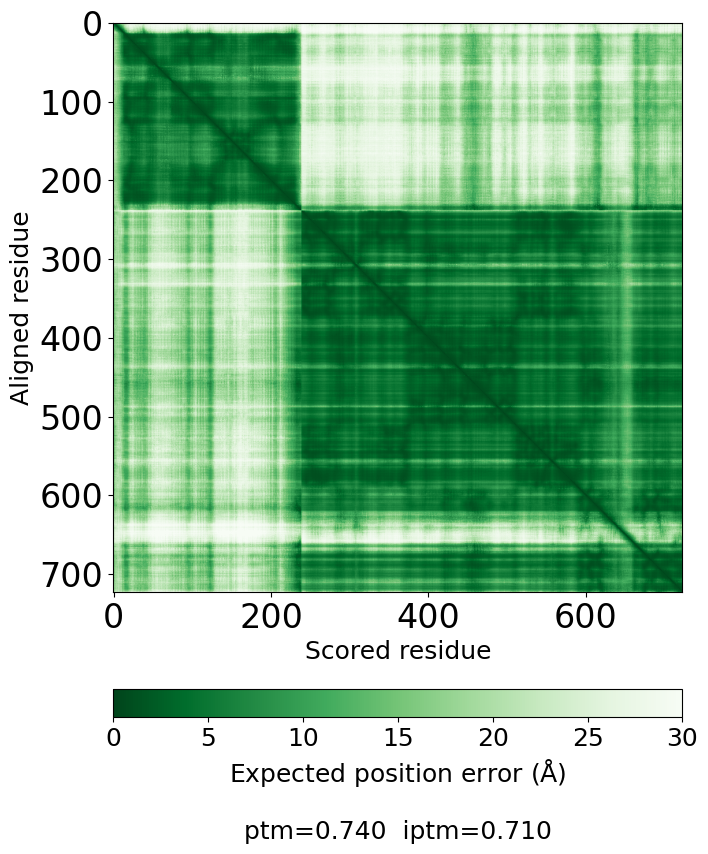

In [84]:
if __name__ == "__main__":
    input_json_file = "/Users/busra/Library/CloudStorage/GoogleDrive-busra.savas@ibg.edu.tr/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-aifm1-seed5_unpaired/pae/ak2-aifm1-seed5-unpaired_0_scores_rank_001_alphafold2_ptm_model_5_seed_003.json"
    output_base_name = os.path.splitext(input_json_file)[0]
    plot_pae(input_json_file, output_base_name)

#### Close-up view for residue 230-239

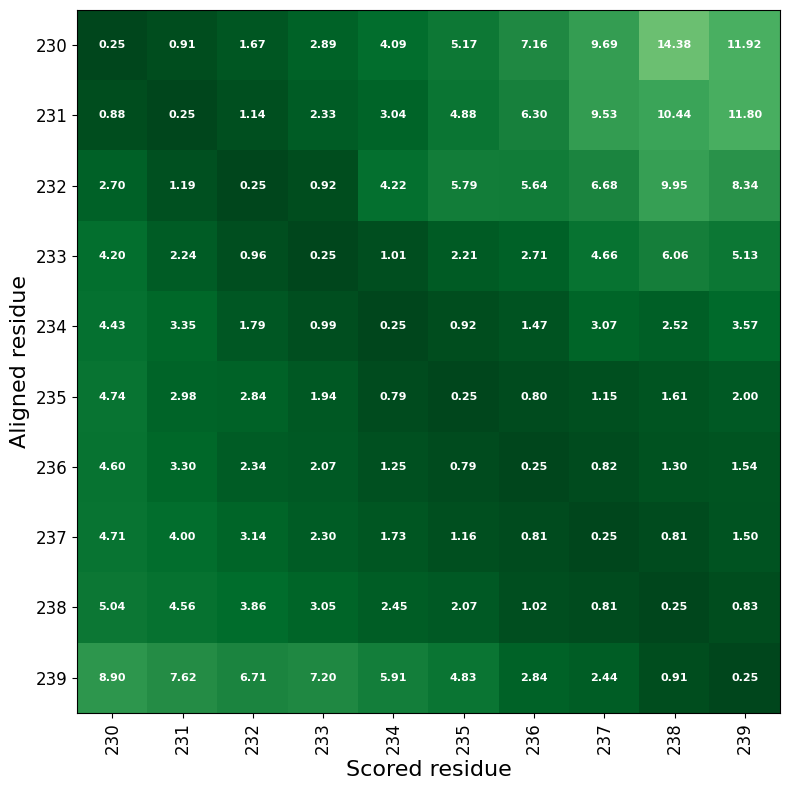

In [85]:
if __name__ == "__main__":
    input_json_file = "/Users/busra/Library/CloudStorage/GoogleDrive-busra.savas@ibg.edu.tr/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-aifm1-seed5_unpaired/pae/ak2-aifm1-seed5-unpaired_0_scores_rank_001_alphafold2_ptm_model_5_seed_003.json"
    start_residue_number = 230
    end_residue_number = 239

    plot_pae_zoomed(input_json_file, start_residue_number, end_residue_number)

## All-to-all distogram for AK2 residue 230 | S2

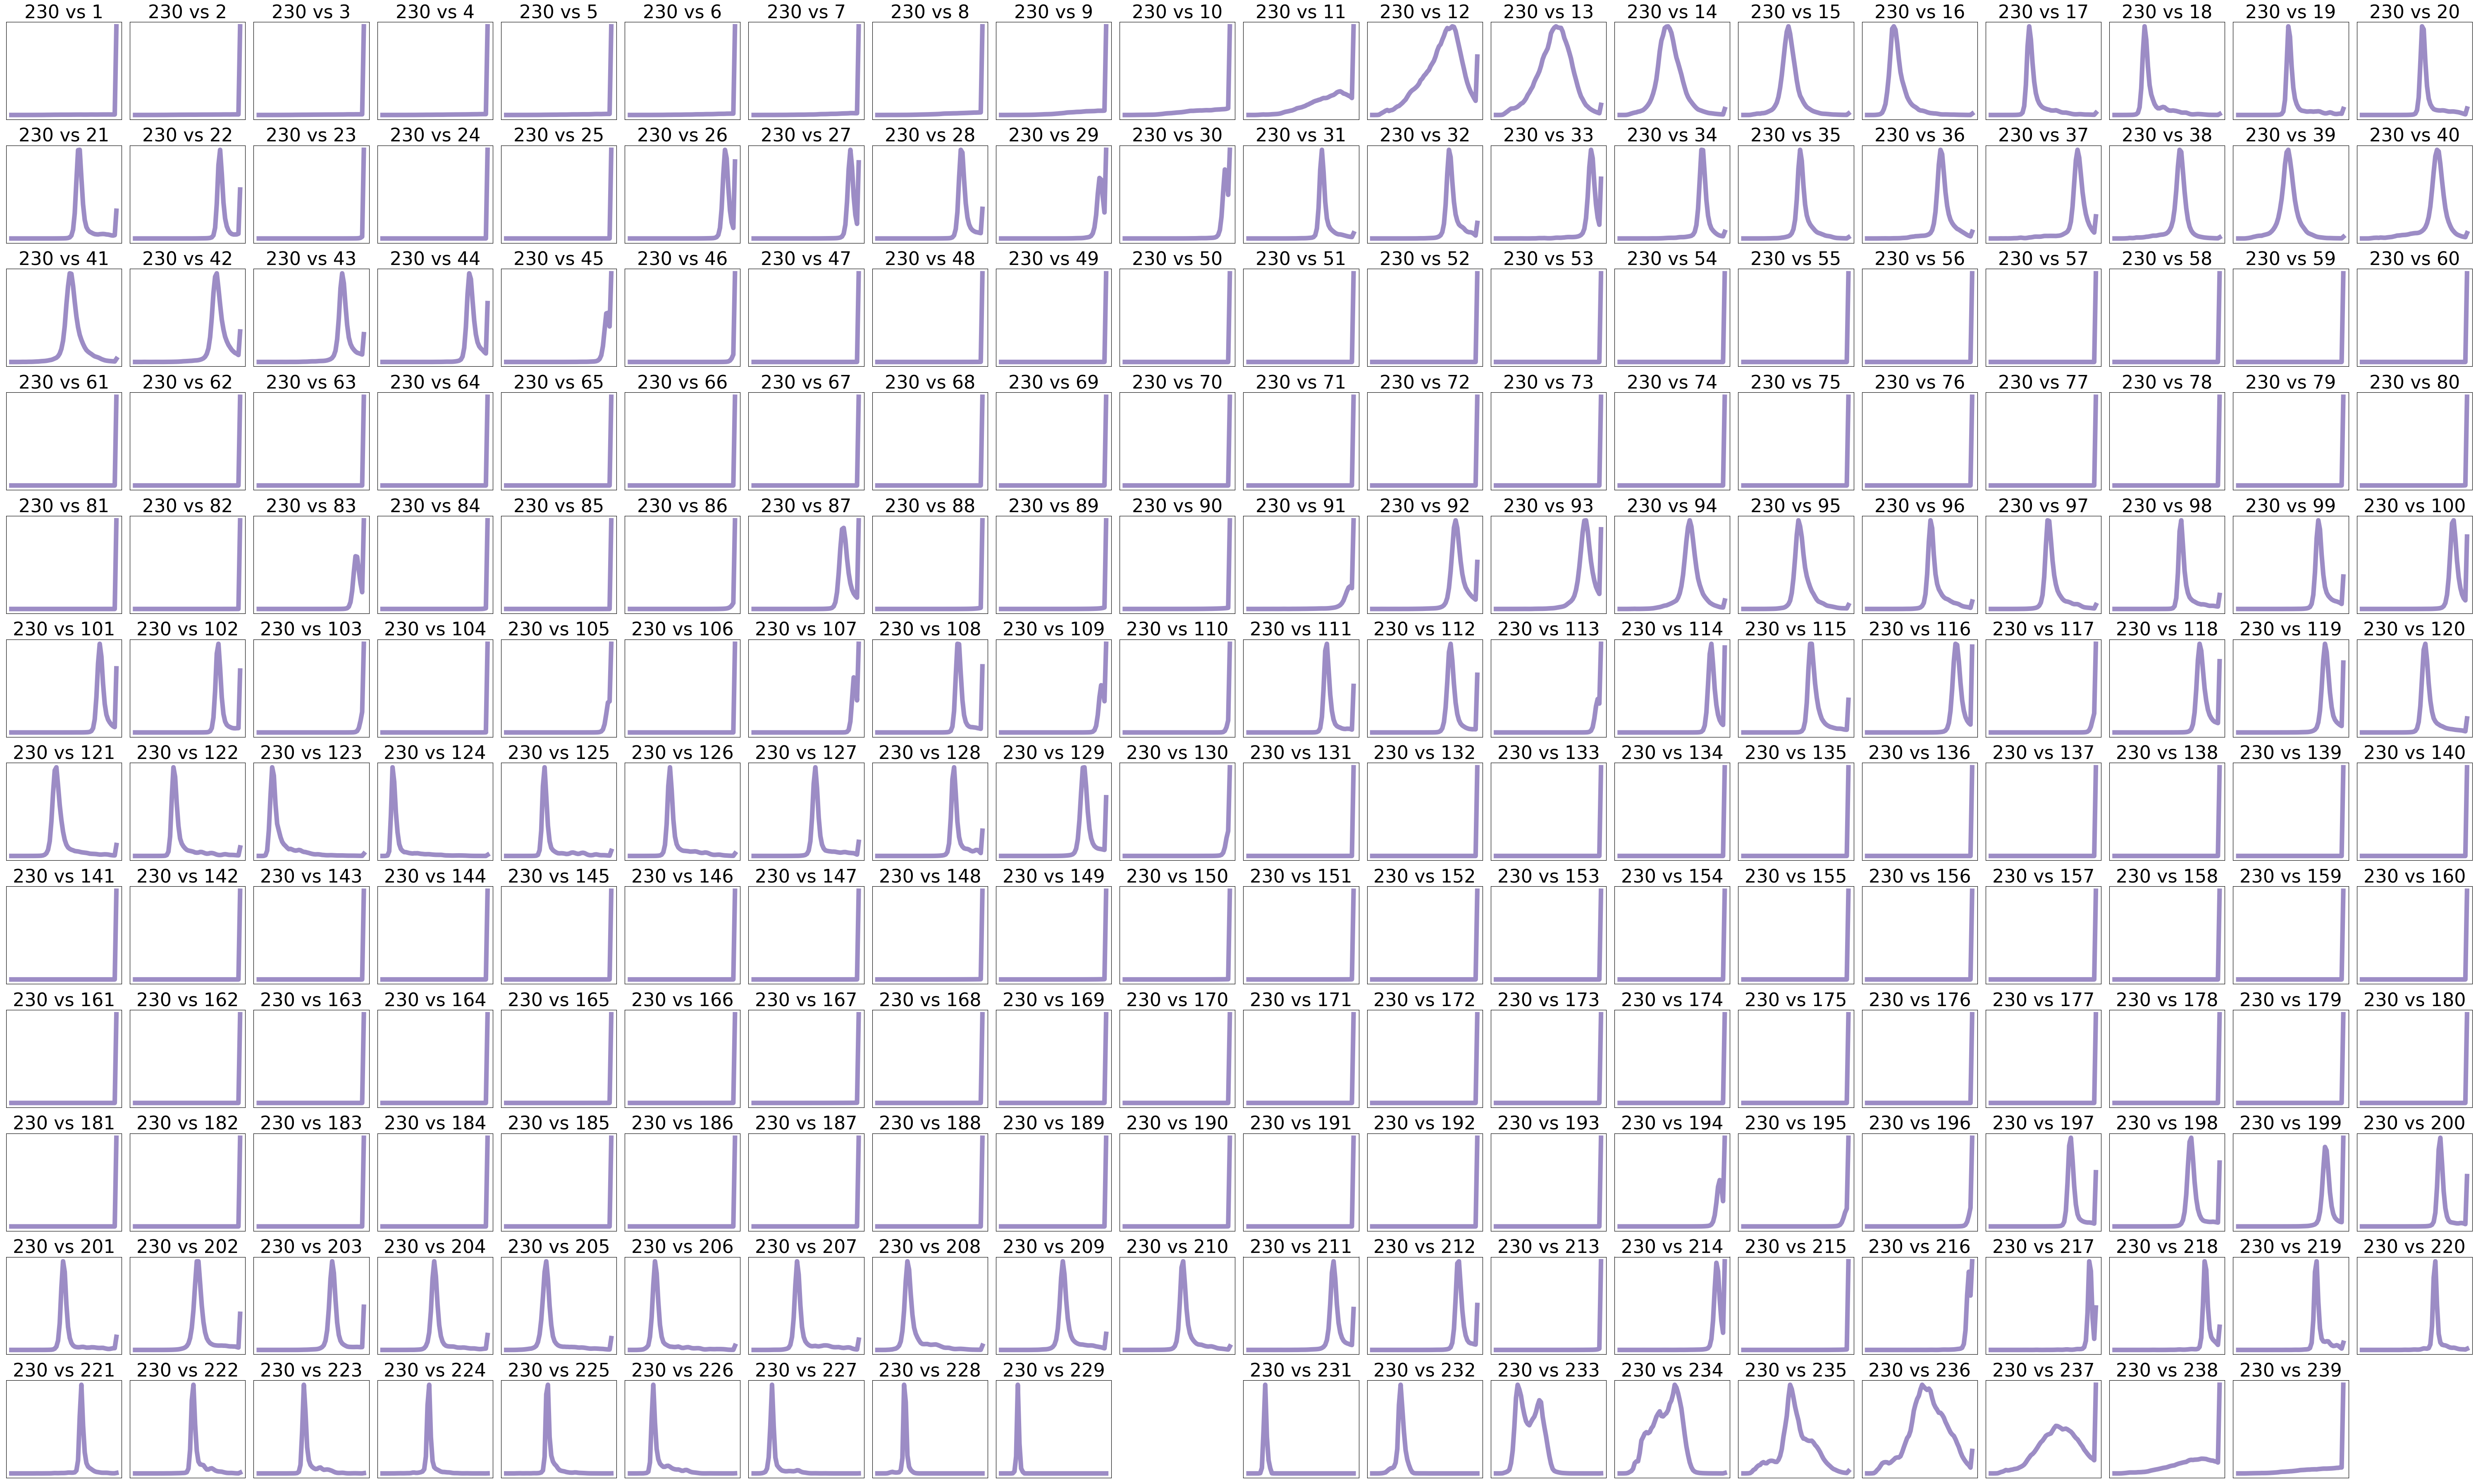

In [86]:
for res_id in range(230, 231):
    plot_distogram_for_a_residue(
        '/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-seed5/distograms/ak2-seed5_0_all_rank_001_alphafold2_ptm_model_3_seed_000.pickle',
        res_id,
        save_fig=True,
        fig_name=f"/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-seed5/all-to-all-dist-figs/all-distogram_residue_{res_id}_subplots.png"
    )


## MD-based marker hinge distance distribution for holo AK2/AIFM1 | S3

Mean distance: 10.16 Å
Median distance: 9.97 Å


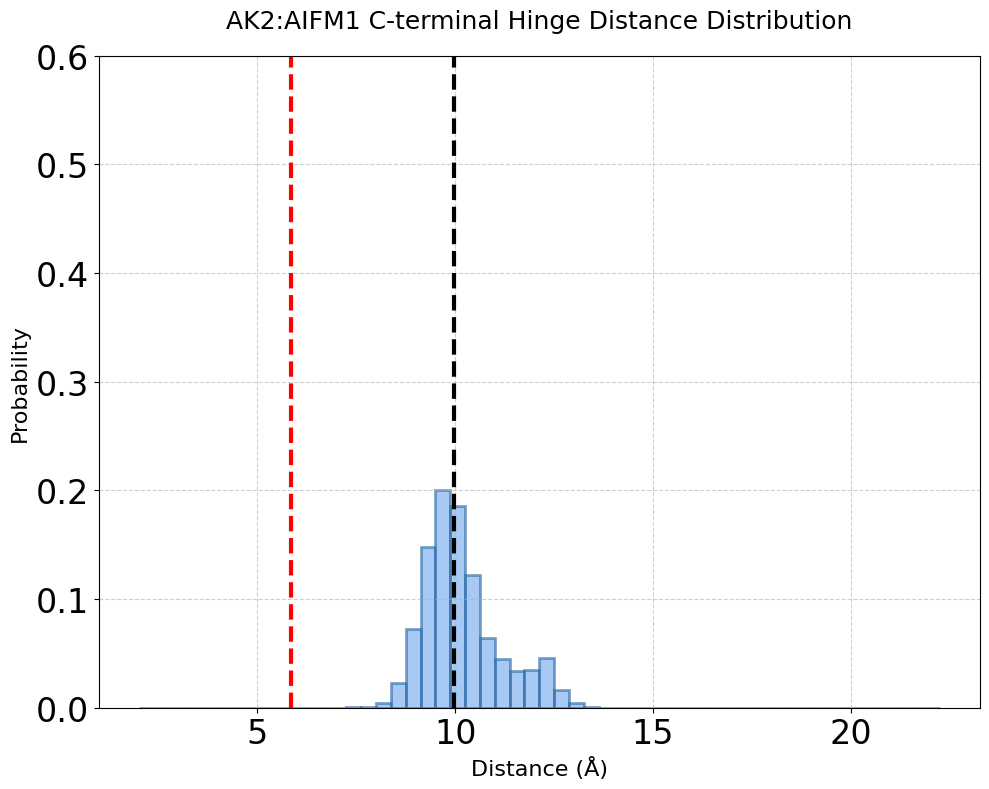

In [110]:
plot_distance_normalized_frequency(
    csv_file="/Users/busra/Desktop/distogram/FEBS/MD/230_233_complex_merged.dist",
    title="AK2:AIFM1 C-terminal Hinge Distance Distribution",
    color="#6DA5ED",
    edgecolor="#2866A3",
    output_filename="230_233_complex_merged"
)

## Paired-unpaired MSA difference across versions | Figure S4

### Unpaired

#### AF2-ptm

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/distogram_distribution_ak2-aifm1_unpaired_af2ptm_res230_233.png


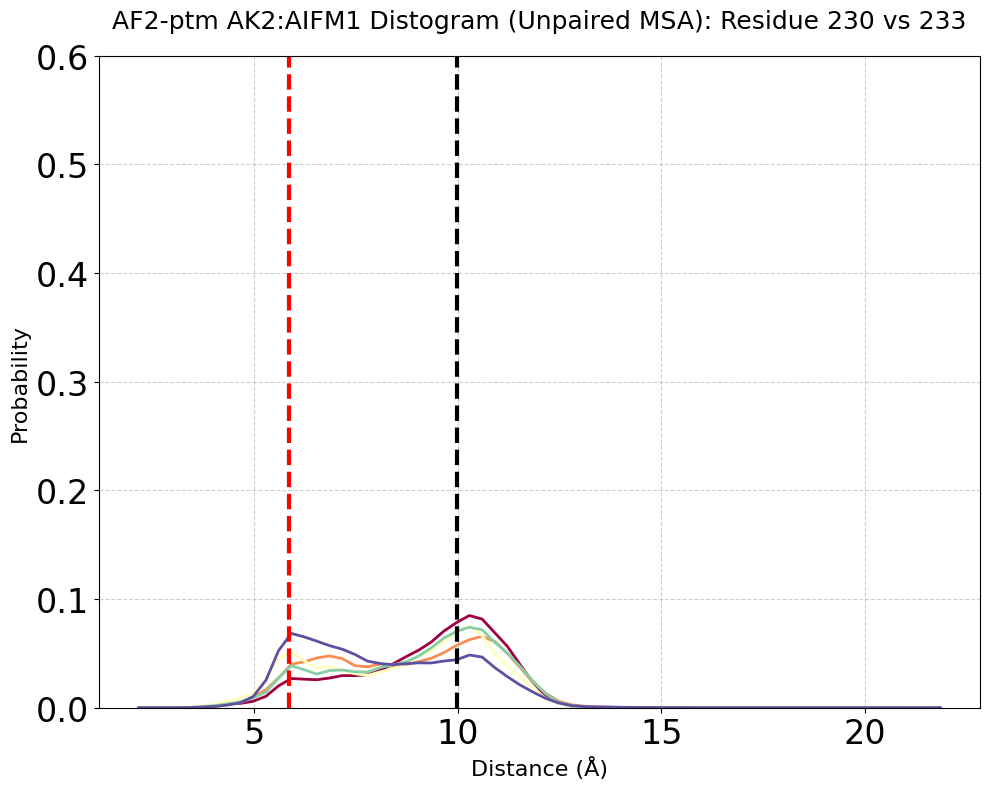

In [87]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-aifm1-unpaired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2-ptm AK2:AIFM1 Distogram (Unpaired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_unpaired_af2ptm_res230_233.png"
)

#### AF2.1

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.1/distogram_distribution_ak2-aifm1_unpaired_af2-1_res230_233.png


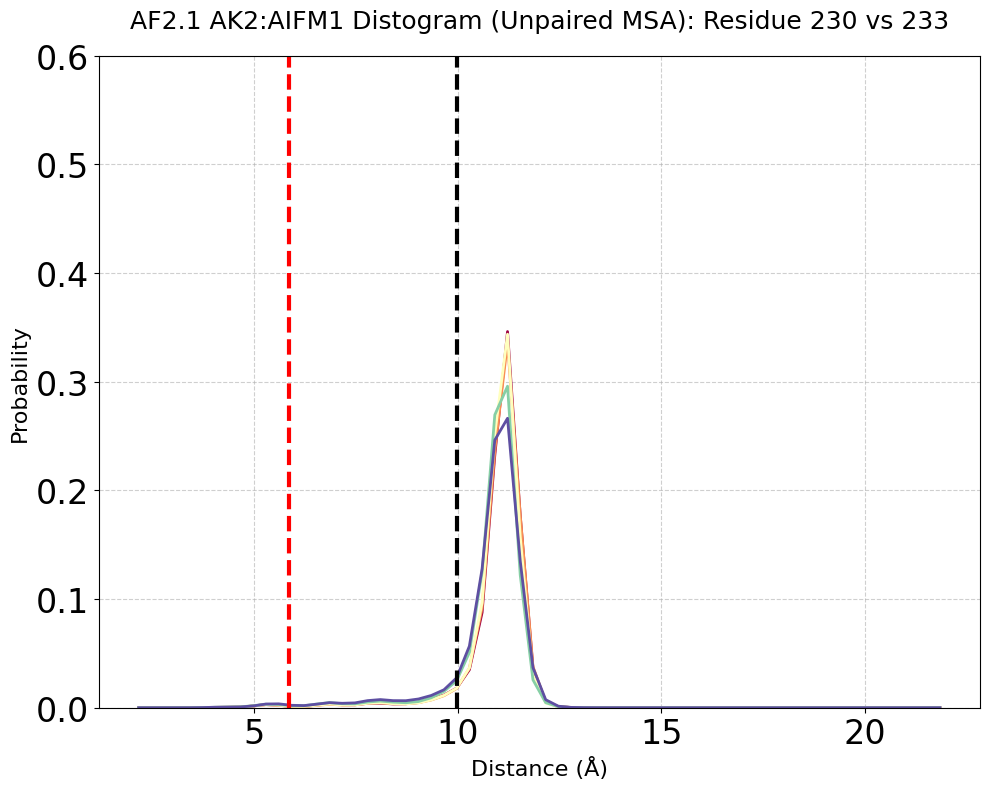

In [88]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.1/ak2-aifm1-unpaired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.1 AK2:AIFM1 Distogram (Unpaired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_unpaired_af2-1_res230_233.png"
)

#### AF2.2

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.2/distogram_distribution_ak2-aifm1_unpaired_af2-2_res230_233.png


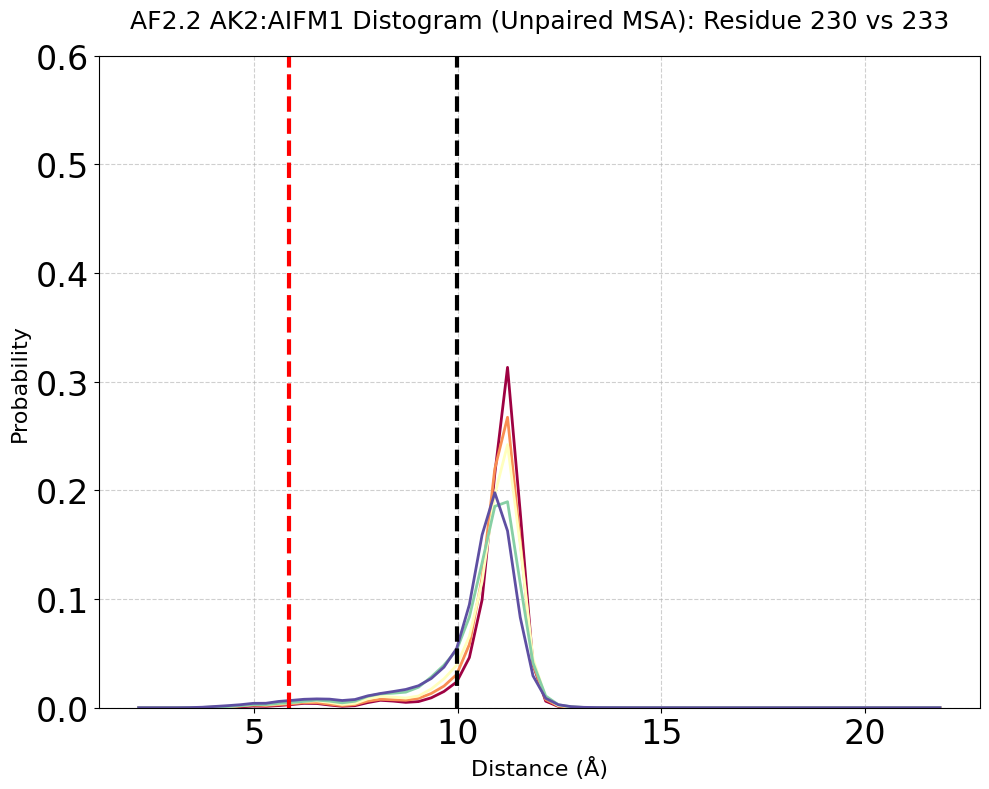

In [89]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.2/ak2-aifm1-unpaired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.2 AK2:AIFM1 Distogram (Unpaired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_unpaired_af2-2_res230_233.png"
)

#### AF2.3

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.3/distogram_distribution_ak2-aifm1_unpaired_af2-3_res230_233.png


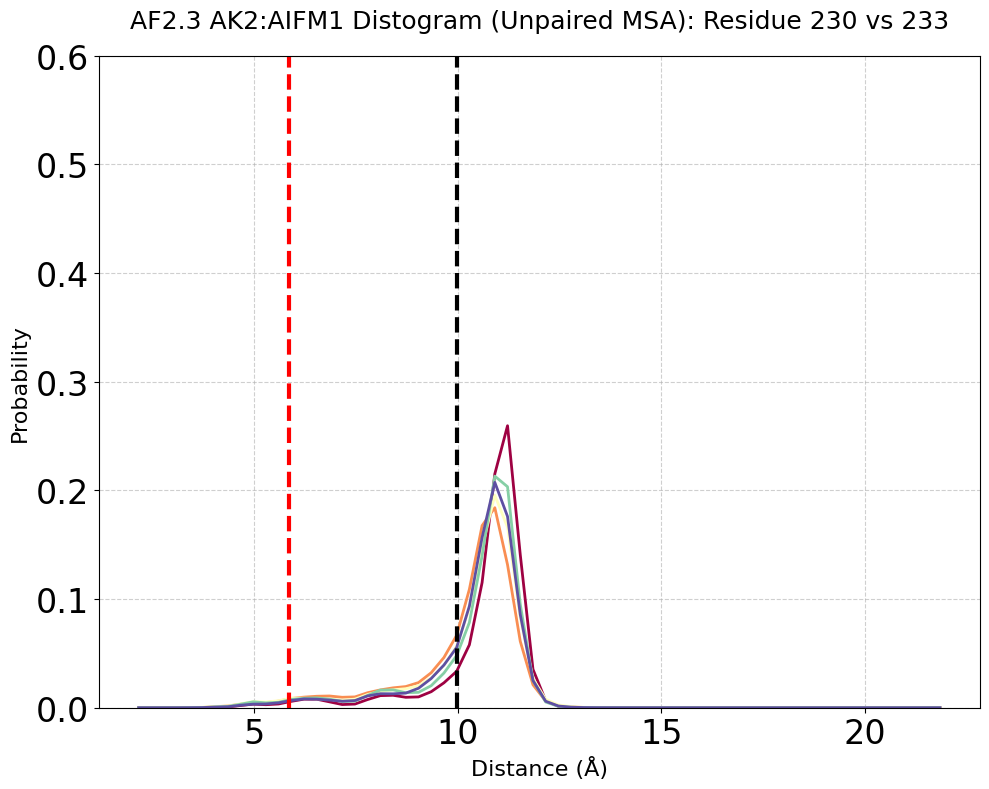

In [90]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.3/ak2-aifm1-unpaired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.3 AK2:AIFM1 Distogram (Unpaired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_unpaired_af2-3_res230_233.png"
)

#### AF3

Plot saved to: /Volumes/Expansion/FEBS/paired-unpaired-distograms/af3/distogram_distribution_af3_ak2-aifm1-unpaired_res230_233.png


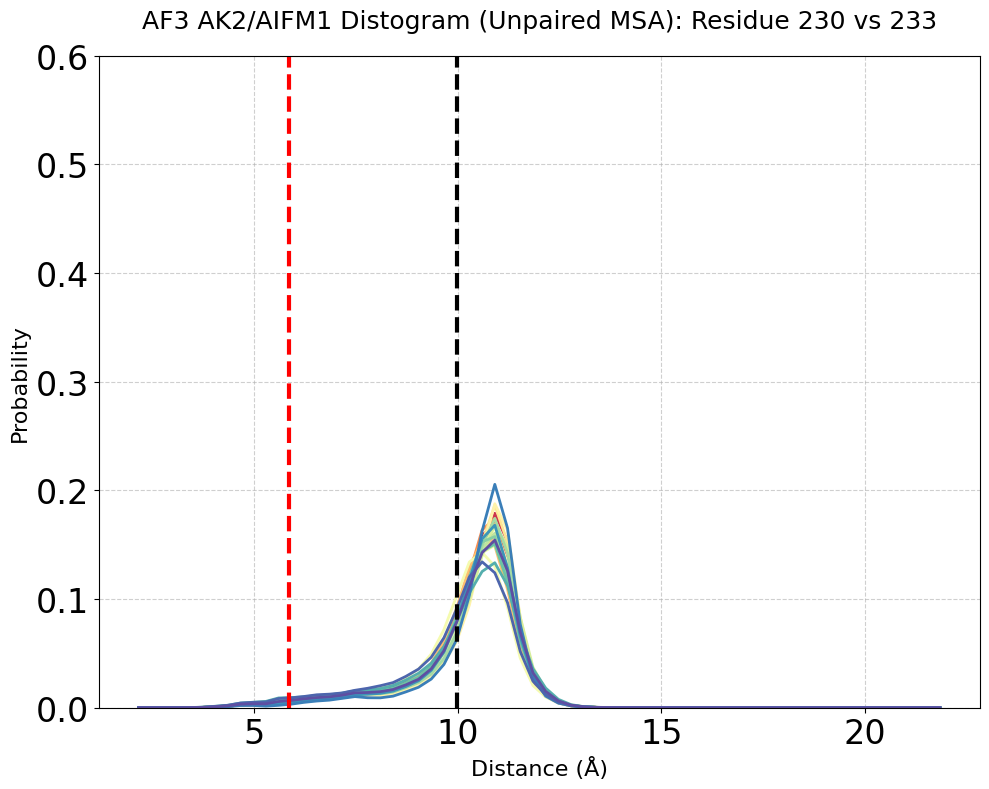

In [96]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Volumes/Expansion/FEBS/paired-unpaired-distograms/af3/ak2-aifm1-unpaired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF3 AK2/AIFM1 Distogram (Unpaired MSA): Residue {res_i} vs {res_j}"
)

### Paired

#### AF2-ptm

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/distogram_distribution_ak2-aifm1_paired_af2ptm_res230_233.png


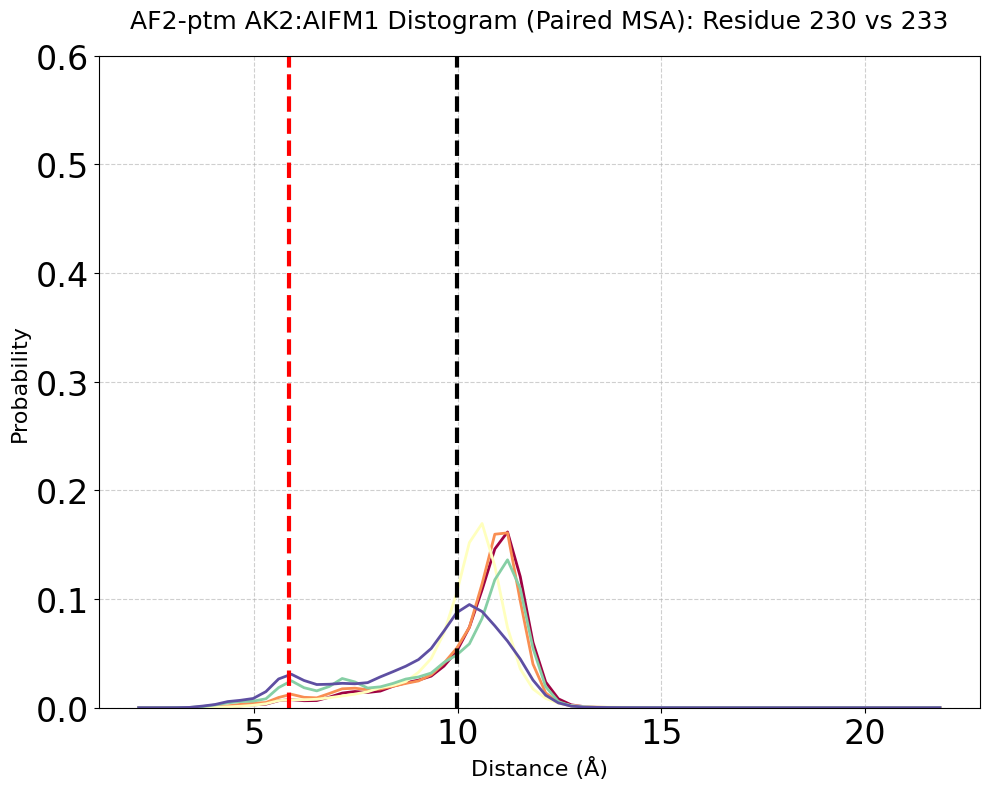

In [92]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2-ptm/ak2-aifm1-paired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2-ptm AK2:AIFM1 Distogram (Paired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_paired_af2ptm_res230_233.png"
)

#### AF2.1

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.1/distogram_distribution_ak2-aifm1_paired_af2-1_res230_233.png


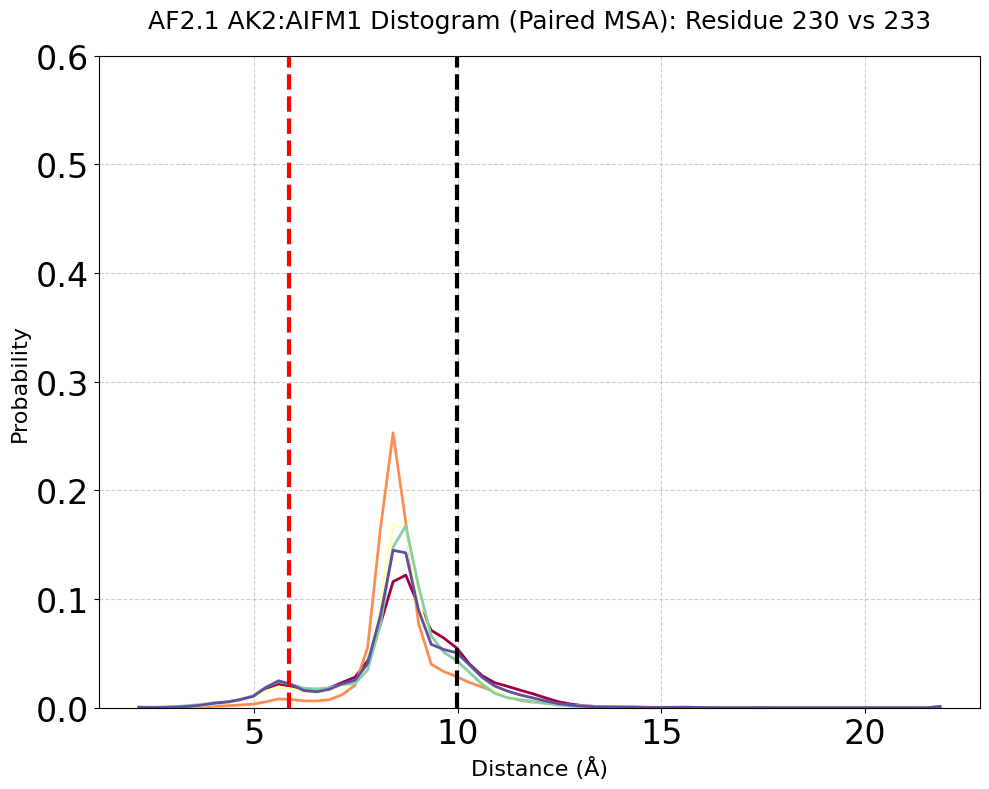

In [93]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.1/ak2-aifm1-paired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.1 AK2:AIFM1 Distogram (Paired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_paired_af2-1_res230_233.png"
)

#### AF2.2

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.2/distogram_distribution_ak2-aifm1_paired_af2-2_res230_233.png


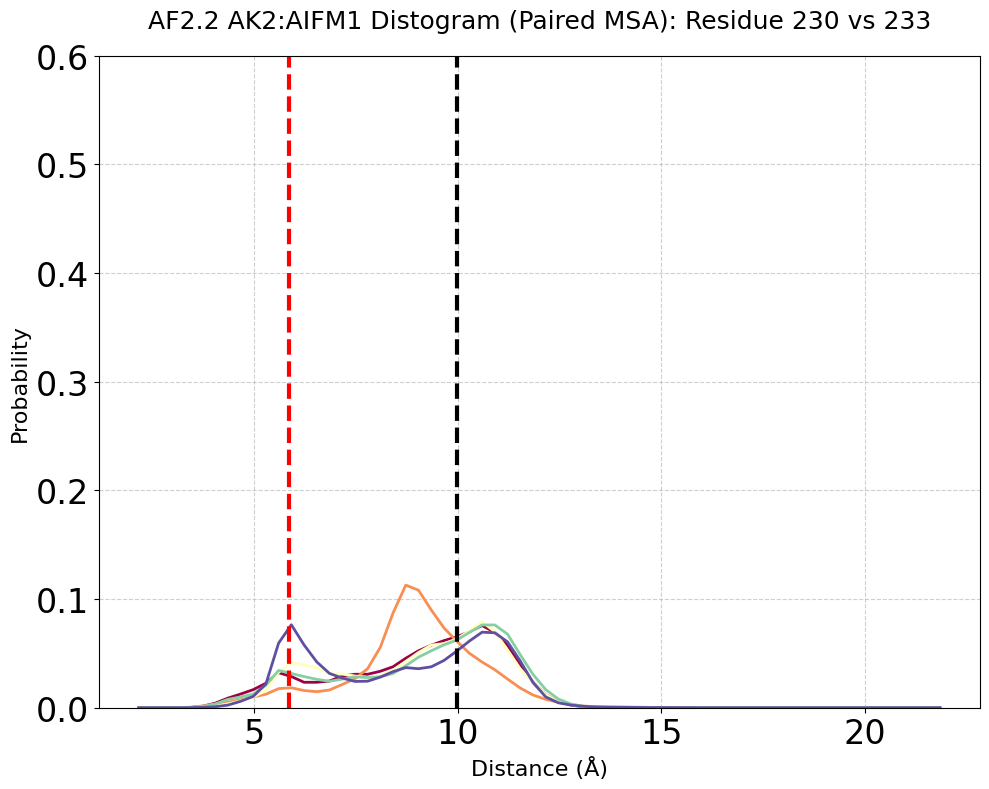

In [94]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.2/ak2-aifm1-paired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.2 AK2:AIFM1 Distogram (Paired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_paired_af2-2_res230_233.png"
)

#### AF2.3

Plot saved to: /Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.3/distogram_distribution_ak2-aifm1_paired_af2-3_res230_233.png


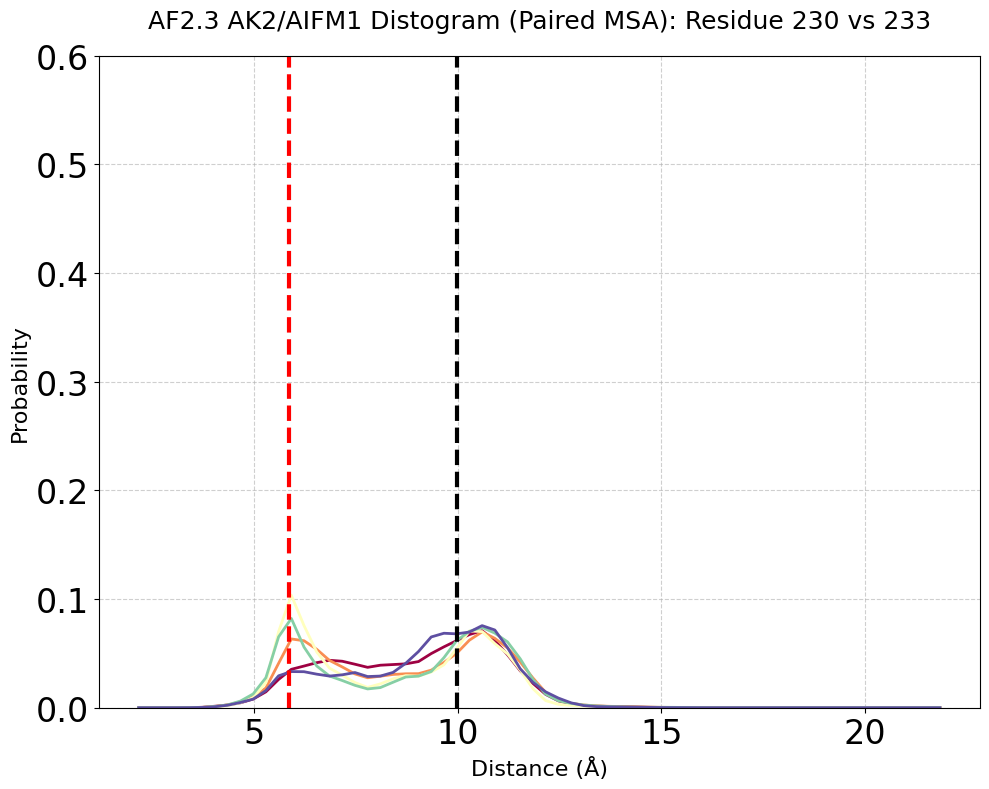

In [95]:
res_i = 230
res_j = 233
plot_all_distograms_in_directory(
    "/Users/busra/Google Drive/Shared drives/CSB-Karaca Lab/Projects/AF-distogram/raw-data/af2.3/ak2-aifm1-paired/distograms",
    res_i=res_i,
    res_j=res_j,
    title=f"AF2.3 AK2/AIFM1 Distogram (Paired MSA): Residue {res_i} vs {res_j}",
    output_filename="distogram_distribution_ak2-aifm1_paired_af2-3_res230_233.png"
)

## Distogram profiles through recycles | Figure S5

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import re
import sys
from matplotlib.ticker import FuncFormatter

# Fake-import to bypass the missing module reference
sys.modules['np.core.multiarray'] = np.core.multiarray

def plot_distogram_line(file_paths, res_i, res_j, temperature=1.0,
                        highlight_distances=[6.4, 11.0], ylim=(0, 0.12)):
    """
    Plot distogram line plot for a specific residue pair from one or multiple files.
    Supports both .npz and .pickle files.
    Uses 'r0', 'r1', etc. from the filename as label.
    """
    if isinstance(file_paths, str):
        file_paths = [file_paths]

    # Predefined styles (up to 4 files)
    line_styles = [
        ('#B5A8D5', ':'),  # light gray dashed
        ('#7A73D1', ':'),  # darker gray dashed
        ('#4D55CC', ':'),  # even darker gray dashed
        ('#211C84', '-')      # black solid
    ]

    plt.figure(figsize=(8, 8))

    for idx, file_path in enumerate(file_paths):
        # Auto-detect and load
        if file_path.endswith(".npz"):
            data = np.load(file_path)
            logits = data['logits']
            bin_edges = data['bin_edges']
        elif file_path.endswith(".pickle"):
            with open(file_path, "rb") as f:
                distogram_data = pickle.load(f)
            logits = distogram_data['distogram']['logits']
            bin_edges = distogram_data['distogram']['bin_edges']
        else:
            raise ValueError("Unsupported file type. Must be .npz or .pickle")

        logits = logits[..., :len(bin_edges) - 1]
        scaled_logits = logits / temperature
        exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=-1, keepdims=True))
        probabilities = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

        probs = probabilities[res_i - 1, res_j - 1, :]
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        # Extract label from filename (looking for 'r0', 'r1', etc.)
        filename = os.path.basename(file_path)
        rank_match = re.search(r'(r\d+)', filename)
        label = rank_match.group(1) if rank_match else filename

        # Get color and linestyle based on index
        color, linestyle = line_styles[min(idx, len(line_styles) - 1)]
        plt.plot(bin_centers, probs, linestyle=linestyle, color=color, linewidth=4, label=label)

    # Highlight distances with fixed colors
    for d in highlight_distances:
        if d == 5.86:
            plt.axvline(x=d, color='red', linestyle='--', linewidth=2)
        elif d == 9.97:
            plt.axvline(x=d, color='black', linestyle='--', linewidth=2)

    plt.title(f'Residue {res_i} - Residue {res_j}', fontsize=28)
    plt.xlabel('Distance (Å)', fontsize=24)
    plt.ylabel('Probability', fontsize=24)
    plt.xticks([5, 10, 15, 20])
    plt.ylim(0, 0.2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', which='major', labelsize=18)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.2f}"))

    # Legend under the plot
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=14, frameon=False)
    plt.tight_layout()
    plt.show()

### AK2

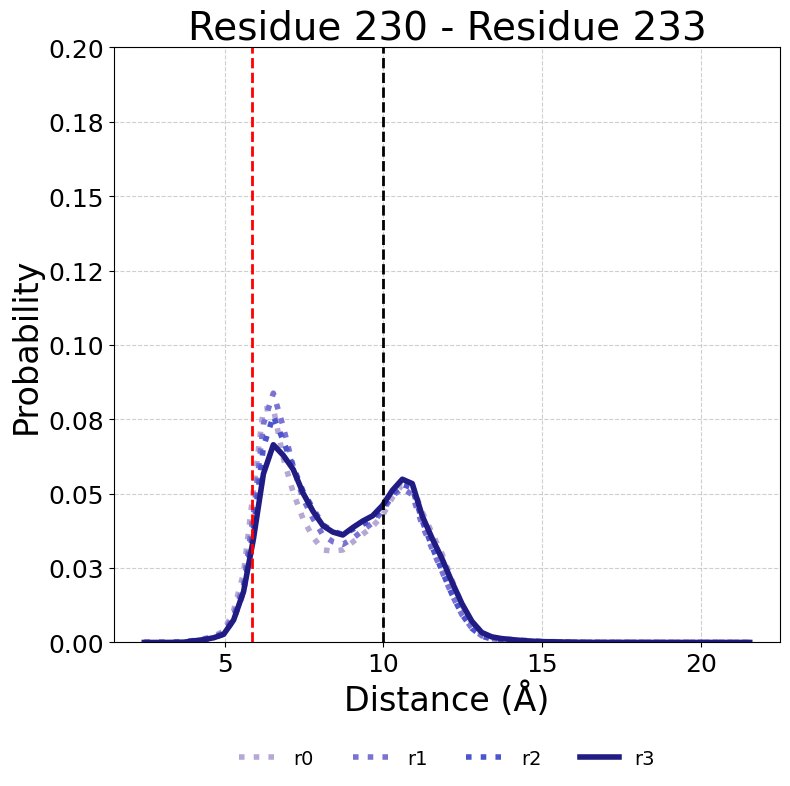

In [12]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2/ak2-seed5_0_all_rank_001_alphafold2_ptm_model_3_seed_000.r0.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2/ak2-seed5_0_all_rank_001_alphafold2_ptm_model_3_seed_000.r1.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2/ak2-seed5_0_all_rank_001_alphafold2_ptm_model_3_seed_000.r2.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2/ak2-seed5_0_all_rank_001_alphafold2_ptm_model_3_seed_000.r3.pickle"
    ],
    res_i=230,
    res_j=233,
    highlight_distances=[5.86, 9.97]
)

### AK2/AIFM1

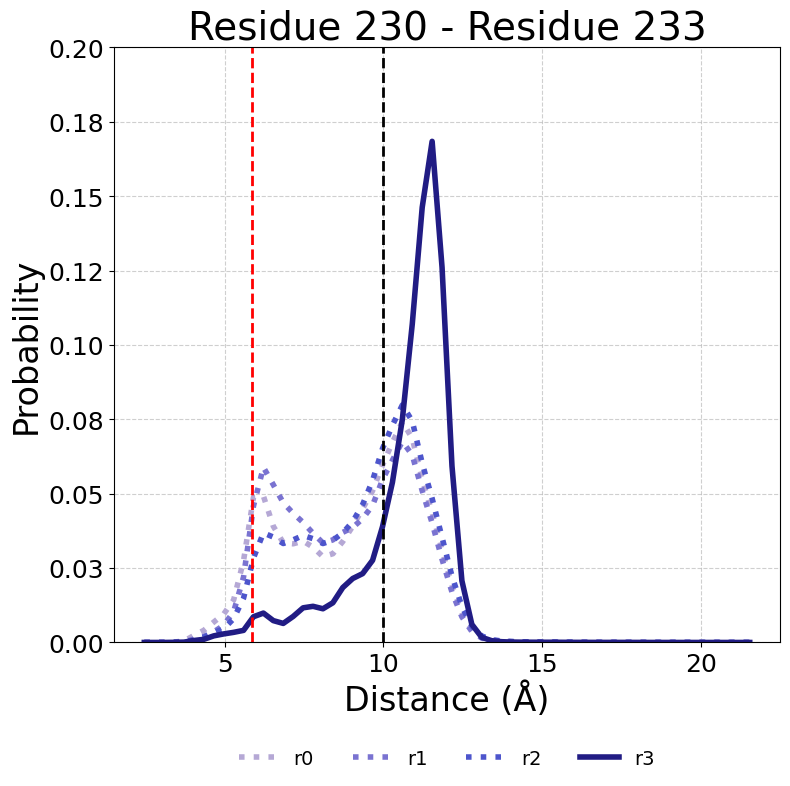

In [13]:
plot_distogram_line(
    ["/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2-aifm1/ak2-aifm1-seed5-unpaired_0_all_rank_001_alphafold2_ptm_model_5_seed_003.r0.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2-aifm1/ak2-aifm1-seed5-unpaired_0_all_rank_001_alphafold2_ptm_model_5_seed_003.r1.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2-aifm1/ak2-aifm1-seed5-unpaired_0_all_rank_001_alphafold2_ptm_model_5_seed_003.r2.pickle",
     "/Volumes/Expansion/FEBS/af2-ptm/distogram-per-recycle/ak2-aifm1/ak2-aifm1-seed5-unpaired_0_all_rank_001_alphafold2_ptm_model_5_seed_003.r3.pickle"
    ],
    res_i=230,
    res_j=233,
    highlight_distances=[5.86, 9.97]
)